# Задание №5: Двухклассовая классификация моторного воображения на основе EEG

Этот Notebook выполняет требования задания:

1. Загрузка обучающей выборки, тестовой выборки и соответствующих target-меток;
2. Описание смысла данных на основе экспериментального контекста PhysioNet EEG Motor Movement/Imagery Dataset;
3. Выполнение вейвлет-преобразования для каждого временного ряда EEG и получение временно-частотных изображений;
4. Использование модели нейронной сети для двухклассовой классификации;
5. Вывод accuracy, отчета классификации, матрицы ошибок и сохранение результатов предсказания.

> Примечание: предоставленные CSV-файлы уже являются обработанными фрагментами данных. Здесь используется формат: «каждая строка = один EEG-образец / trial, каждый столбец = временная точка дискретизации».

## 1. Анализ задания и набора данных

### Исходный экспериментальный контекст

PhysioNet EEG Motor Movement/Imagery Dataset — это набор EEG-данных для задач выполнения движения и моторного воображения. Исходные данные состоят из записей EEG по 64 каналам с частотой дискретизации 160 Hz. В ходе эксперимента испытуемые по визуальной подсказке выполняли или воображали движения левой руки, правой руки, обеих рук или обеих ног.

CSV-файлы, выданные в этом задании, представляют собой двухклассовую версию данных. Цель состоит в том, чтобы по EEG-сигналу определить, к какому классу моторного воображения / движения относится образец, например левый кулак или правый кулак.

### Файлы данного задания

| Файл | Смысл |
|---|---|
| `MI-EEG-B9T.csv` | EEG-сигнал обучающей выборки |
| `2class_MI_EEG_train_9.csv` | Метки обучающей выборки |
| `MI-EEG-B9E.csv` | EEG-сигнал тестовой выборки |
| `2class_MI_EEG_test_9.csv` | Метки тестовой выборки |

### Идея моделирования

EEG является нестационарным временным рядом, поэтому анализ только исходной формы сигнала недостаточно нагляден. Вейвлет-преобразование позволяет преобразовать сигнал в двумерное изображение «время — масштаб / частота», затем это двумерное изображение разворачивается в признаки и подается на вход классификатора нейронной сети. Здесь используются:

- Предобработка: отдельная стандартизация каждого trial;
- Извлечение признаков: Morlet-вейвлет-преобразование;
- Классификационная модель: нейронная сеть MLP, многослойный перцептрон;
- Метрики оценки: accuracy, precision, recall, F1-score, confusion matrix.

In [1]:
# =========================
# 2. Импорт зависимостей
# =========================

from pathlib import Path
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import fftconvolve

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

# Фиксация случайного зерна для максимально воспроизводимых результатов
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

plt.rcParams["figure.dpi"] = 120

In [2]:
# =========================
# 3. Настройка путей к данным
# =========================
# Если вы запускаете Notebook локально, поместите четыре CSV-файла в тот же каталог, что и текущий Notebook.
# Если запуск выполняется на этой платформе, файлы могут находиться в /mnt/data.

CANDIDATE_DIRS = [Path("."), Path("/mnt/data")]

required_files = {
    "X_train": "MI-EEG-B9T.csv",
    "y_train": "2class_MI_EEG_train_9.csv",
    "X_test": "MI-EEG-B9E.csv",
    "y_test": "2class_MI_EEG_test_9.csv",
}

DATA_DIR = None
for d in CANDIDATE_DIRS:
    if all((d / fname).exists() for fname in required_files.values()):
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Не найдены все необходимые файлы данных. Убедитесь, что четыре CSV-файла находятся в одном каталоге с Notebook,"
        "или вручную измените DATA_DIR."
    )

print("Каталог данных:", DATA_DIR.resolve())

paths = {k: DATA_DIR / v for k, v in required_files.items()}
for k, p in paths.items():
    print(f"{k}: {p}")

Каталог данных: C:\Users\lenovo\Desktop\研二\人工系统
X_train: MI-EEG-B9T.csv
y_train: 2class_MI_EEG_train_9.csv
X_test: MI-EEG-B9E.csv
y_test: 2class_MI_EEG_test_9.csv


In [3]:
# =========================
# 4. Чтение данных
# =========================
# Внимание: у этих CSV-файлов нет заголовков, поэтому необходимо указать header=None.
# Иначе pandas ошибочно воспримет первую строку как имена столбцов.

X_train = pd.read_csv(paths["X_train"], header=None).values.astype(np.float32)
y_train = pd.read_csv(paths["y_train"], header=None).values.ravel().astype(int)

X_test = pd.read_csv(paths["X_test"], header=None).values.astype(np.float32)
y_test = pd.read_csv(paths["y_test"], header=None).values.ravel().astype(int)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nРаспределение меток в обучающей выборке:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nРаспределение меток в тестовой выборке:")
print(pd.Series(y_test).value_counts().sort_index())

assert X_train.shape[0] == y_train.shape[0], "Количество образцов и меток в обучающей выборке не совпадает"
assert X_test.shape[0] == y_test.shape[0], "Количество образцов и меток в тестовой выборке не совпадает"

X_train shape: (400, 3000)
y_train shape: (400,)
X_test shape : (320, 3000)
y_test shape : (320,)

Распределение меток в обучающей выборке:
0    200
1    200
Name: count, dtype: int64

Распределение меток в тестовой выборке:
0    160
1    160
Name: count, dtype: int64


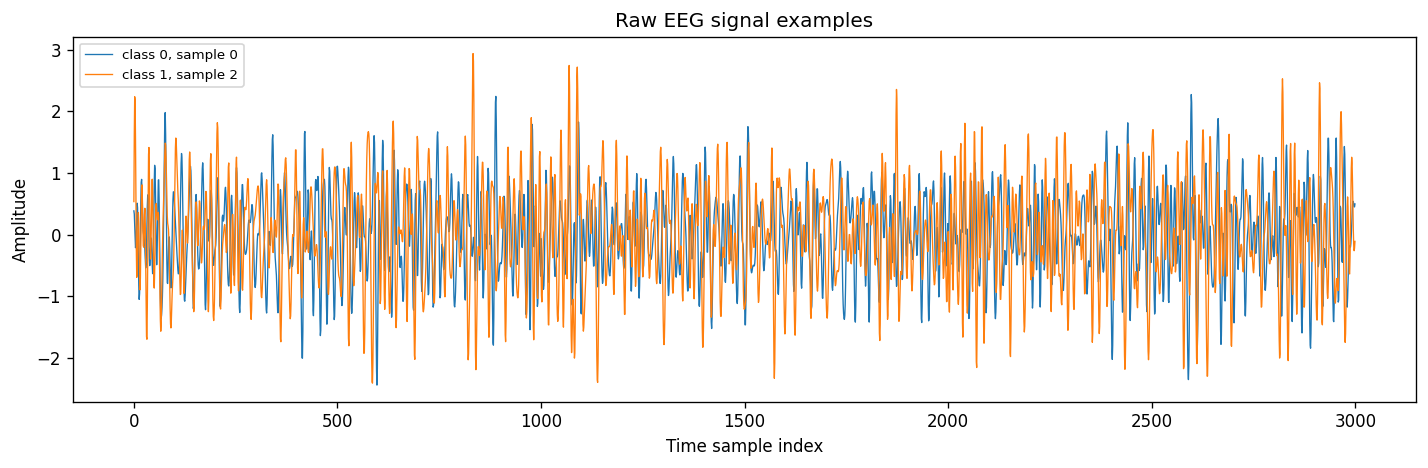

In [4]:
# =========================
# 5. Визуализация исходных временных рядов EEG
# =========================

def plot_raw_examples(X, y, n_each_class=2):
    classes = np.unique(y)
    plt.figure(figsize=(12, 4))

    for cls in classes:
        idxs = np.where(y == cls)[0][:n_each_class]
        for idx in idxs:
            plt.plot(X[idx], linewidth=0.8, label=f"class {cls}, sample {idx}")

    plt.title("Raw EEG signal examples")
    plt.xlabel("Time sample index")
    plt.ylabel("Amplitude")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_raw_examples(X_train, y_train, n_each_class=1)

## 6. Метод вейвлет-преобразования

Здесь не требуется дополнительно устанавливать `PyWavelets`; Morlet continuous wavelet transform реализуется с помощью `numpy + scipy.signal.fftconvolve`.

Процесс обработки:

1. Для каждого EEG-образца отдельно выполняется z-score стандартизация;
2. 3000 временных точек передискретизируются до меньшей длины для сокращения вычислительной нагрузки;
3. Для нескольких масштабов scale выполняется свертка с Morlet-вейвлетом;
4. Получается двумерная матрица: `scale × time`;
5. Используется `log1p` для сжатия диапазона амплитуд, что облегчает обучение нейронной сети.

In [5]:
# =========================
# 7. Функции вейвлет-преобразования
# =========================

def standardize_trials(X, eps=1e-8):
    """
    Отдельная стандартизация каждого trial.
    Это позволяет уменьшить влияние различий амплитуды между образцами на классификацию.
    """
    X = X.astype(np.float32)
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + eps)


def resample_to_length(X, target_len=256):
    """
    Передискретизация каждого временного ряда до фиксированной длины.
    Здесь используется линейная интерполяция, чтобы избежать дополнительных зависимостей.
    """
    n = X.shape[1]
    old_x = np.linspace(0, 1, n, dtype=np.float32)
    new_x = np.linspace(0, 1, target_len, dtype=np.float32)
    X_new = np.vstack([
        np.interp(new_x, old_x, row).astype(np.float32)
        for row in X
    ])
    return X_new


def morlet_wavelet(scale, w=6.0, radius=4.0):
    """
    Генерация комплексного Morlet-вейвлета.

    Чем больше scale, тем заметнее наблюдаемые низкочастотные компоненты;
    чем меньше scale, тем заметнее наблюдаемые высокочастотные компоненты.
    """
    half = int(np.ceil(radius * scale))
    t = np.arange(-half, half + 1, dtype=np.float32)
    ts = t / scale

    wavelet = (np.pi ** -0.25) * np.exp(1j * w * ts) * np.exp(-0.5 * ts ** 2)
    wavelet = wavelet / np.sqrt(scale)
    return wavelet.astype(np.complex64)


def cwt_morlet_1d(x, scales):
    """
    Выполнение Morlet CWT для одного 1D EEG-сигнала.
    Возвращает карту амплитуд вейвлета с shape = [n_scales, n_time].
    """
    coefs = []
    for s in scales:
        wav = morlet_wavelet(float(s))
        conv = fftconvolve(x, np.conj(wav[::-1]), mode="same")
        coefs.append(np.abs(conv).astype(np.float32))
    return np.stack(coefs, axis=0)


def build_cwt_images(X, scales, target_len=256):
    """
    Преобразование набора EEG-сигналов во временно-частотные вейвлет-изображения.

    Возврат:
    images: [n_samples, n_scales, target_len]
    """
    X_std = standardize_trials(X)
    X_rs = resample_to_length(X_std, target_len=target_len)

    images = np.empty((X_rs.shape[0], len(scales), target_len), dtype=np.float32)
    for i, row in enumerate(X_rs):
        images[i] = cwt_morlet_1d(row, scales)

    # Сжатие диапазона амплитуд, аналогично логарифмическому усилению изображения
    images = np.log1p(images)
    return images

In [6]:
# =========================
# 8. Генерация вейвлет-изображений
# =========================

SCALES = np.arange(2, 34, 2)   # 16 масштабов: 2,4,...,32
IMAGE_TIME_LEN = 256           # Сжатие 3000 временных точек до 256 точек

X_train_img = build_cwt_images(X_train, scales=SCALES, target_len=IMAGE_TIME_LEN)
X_test_img = build_cwt_images(X_test, scales=SCALES, target_len=IMAGE_TIME_LEN)

print("X_train_img shape:", X_train_img.shape)
print("X_test_img shape :", X_test_img.shape)

# Смысл shape: [число образцов, число масштабов вейвлета, длина по времени]

X_train_img shape: (400, 16, 256)
X_test_img shape : (320, 16, 256)


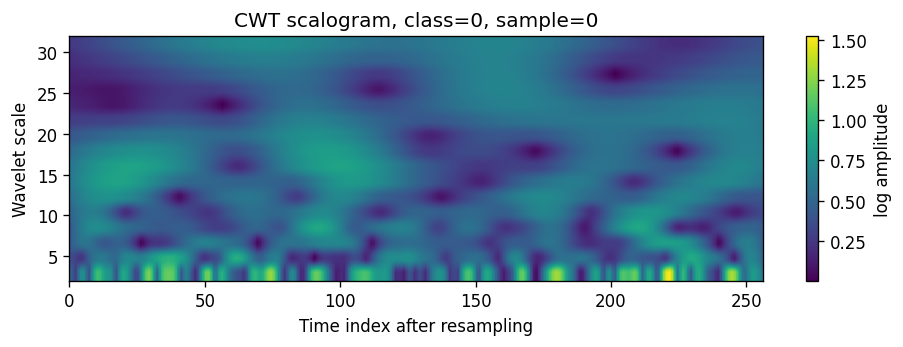

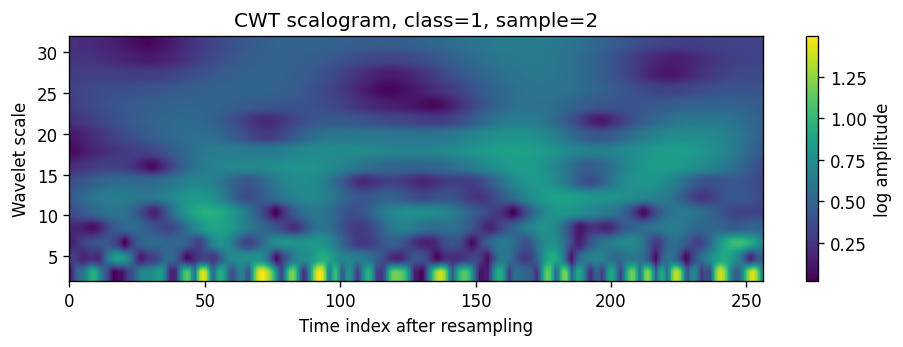

In [7]:
# =========================
# 9. Отображение изображений вейвлет-преобразования
# =========================

def plot_scalogram(image, title="CWT scalogram"):
    plt.figure(figsize=(8, 3))
    plt.imshow(
        image,
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[0, IMAGE_TIME_LEN, SCALES[0], SCALES[-1]]
    )
    plt.colorbar(label="log amplitude")
    plt.xlabel("Time index after resampling")
    plt.ylabel("Wavelet scale")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Отображение одного изображения для каждого класса
for cls in np.unique(y_train):
    idx = np.where(y_train == cls)[0][0]
    plot_scalogram(X_train_img[idx], title=f"CWT scalogram, class={cls}, sample={idx}")

In [8]:
# =========================
# 10. Сохранение нескольких вейвлет-изображений как материалов для демонстрации задания
# =========================

OUTPUT_DIR = DATA_DIR / "eeg_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

for cls in np.unique(y_train):
    idx = np.where(y_train == cls)[0][0]
    plt.figure(figsize=(8, 3))
    plt.imshow(
        X_train_img[idx],
        aspect="auto",
        origin="lower",
        cmap="viridis",
        extent=[0, IMAGE_TIME_LEN, SCALES[0], SCALES[-1]]
    )
    plt.colorbar(label="log amplitude")
    plt.xlabel("Time index after resampling")
    plt.ylabel("Wavelet scale")
    plt.title(f"CWT scalogram, class={cls}, sample={idx}")
    plt.tight_layout()
    save_path = OUTPUT_DIR / f"cwt_class_{cls}_sample_{idx}.png"
    plt.savefig(save_path, bbox_inches="tight")
    plt.close()
    print("Сохранено:", save_path)

Сохранено: eeg_outputs\cwt_class_0_sample_0.png
Сохранено: eeg_outputs\cwt_class_1_sample_2.png


## 11. Формирование входных данных для нейронной сети

Вейвлет-изображение изначально является двумерной матрицей. Чтобы использовать нейронную сеть MLP, его необходимо сначала развернуть в одномерный вектор:

\[
[n\_samples, n\_scales, n\_time] \rightarrow [n\_samples, n\_scales \times n\_time]
\]

Затем применяется общая стандартизация с помощью `StandardScaler`.

In [9]:
# =========================
# 12. Развертывание признаков и стандартизация
# =========================

X_train_feat = X_train_img.reshape(X_train_img.shape[0], -1)
X_test_feat = X_test_img.reshape(X_test_img.shape[0], -1)

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat = scaler.transform(X_test_feat)

print("X_train_feat shape:", X_train_feat.shape)
print("X_test_feat shape :", X_test_feat.shape)

X_train_feat shape: (400, 4096)
X_test_feat shape : (320, 4096)


In [10]:
# =========================
# 13. Разделение на обучающую и валидационную выборки
# =========================

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_feat,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print("Обучающее подмножество:", X_tr.shape, y_tr.shape)
print("Валидационное подмножество:", X_val.shape, y_val.shape)

Обучающее подмножество: (320, 4096) (320,)
Валидационное подмножество: (80, 4096) (80,)


In [11]:
# =========================
# 14. Создание и обучение нейронной сети MLP
# =========================
# MLPClassifier — это классическая прямонаправленная нейронная сеть:
# input -> hidden layer 1 -> hidden layer 2 -> output

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=150,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=12,
    random_state=SEED,
    verbose=True
)

mlp.fit(X_tr, y_tr)

print("\nОбучение завершено")
print("Фактическое число итераций:", mlp.n_iter_)

Iteration 1, loss = 0.85831599
Validation score: 0.645833
Iteration 2, loss = 0.27900127
Validation score: 0.666667
Iteration 3, loss = 0.10587196
Validation score: 0.645833
Iteration 4, loss = 0.03833428
Validation score: 0.687500
Iteration 5, loss = 0.01947331
Validation score: 0.687500
Iteration 6, loss = 0.01162307
Validation score: 0.687500
Iteration 7, loss = 0.00772894
Validation score: 0.687500
Iteration 8, loss = 0.00594753
Validation score: 0.687500
Iteration 9, loss = 0.00484994
Validation score: 0.687500
Iteration 10, loss = 0.00408057
Validation score: 0.687500
Iteration 11, loss = 0.00360560
Validation score: 0.687500
Iteration 12, loss = 0.00320312
Validation score: 0.687500
Iteration 13, loss = 0.00291549
Validation score: 0.687500
Iteration 14, loss = 0.00268451
Validation score: 0.687500
Iteration 15, loss = 0.00247592
Validation score: 0.687500
Iteration 16, loss = 0.00231320
Validation score: 0.687500
Iteration 17, loss = 0.00216429
Validation score: 0.687500
Valida

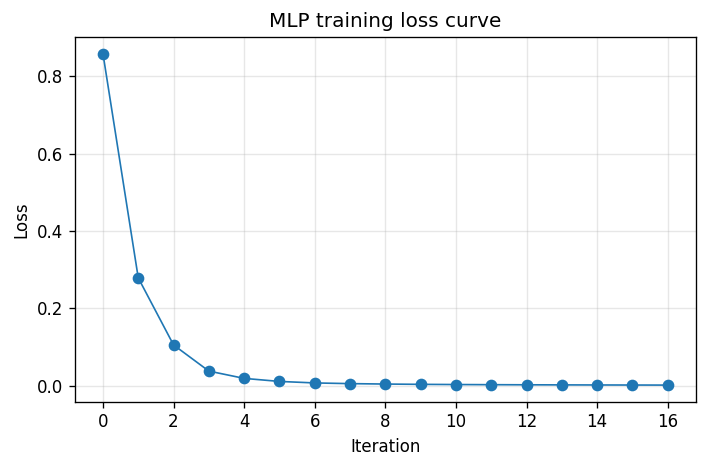

In [12]:
# =========================
# 15. Построение кривой training loss
# =========================

plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_, marker="o", linewidth=1)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("MLP training loss curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# =========================
# 16. Результаты на валидационной выборке
# =========================

y_val_pred = mlp.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_acc)
print("\nValidation classification report:")
print(classification_report(y_val, y_val_pred, digits=4))

Validation accuracy: 0.6375

Validation classification report:
              precision    recall  f1-score   support

           0     0.6279    0.6750    0.6506        40
           1     0.6486    0.6000    0.6234        40

    accuracy                         0.6375        80
   macro avg     0.6383    0.6375    0.6370        80
weighted avg     0.6383    0.6375    0.6370        80



In [14]:
# =========================
# 17. Результаты на тестовой выборке
# =========================

y_test_pred = mlp.predict(X_test_feat)
test_acc = accuracy_score(y_test, y_test_pred)

print("Test accuracy:", test_acc)
print("\nTest classification report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test accuracy: 0.6625

Test classification report:
              precision    recall  f1-score   support

           0     0.6477    0.7125    0.6786       160
           1     0.6806    0.6125    0.6447       160

    accuracy                         0.6625       320
   macro avg     0.6641    0.6625    0.6617       320
weighted avg     0.6641    0.6625    0.6617       320



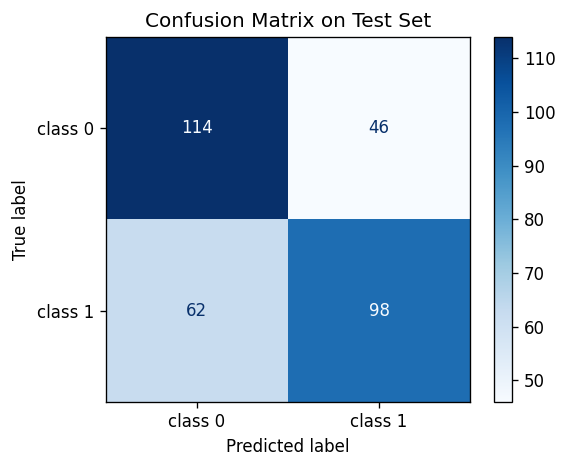

In [15]:
# =========================
# 18. Матрица ошибок
# =========================

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f"class {c}" for c in np.unique(y_train)]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()

In [16]:
# =========================
# 19. Сохранение модели, стандартизатора и результатов предсказания
# =========================

model_path = OUTPUT_DIR / "mlp_cwt_eeg_model.joblib"
scaler_path = OUTPUT_DIR / "feature_scaler.joblib"
pred_path = OUTPUT_DIR / "test_predictions.csv"

joblib.dump(mlp, model_path)
joblib.dump(scaler, scaler_path)

pred_df = pd.DataFrame({
    "sample_id": np.arange(len(y_test)),
    "true_label": y_test,
    "pred_label": y_test_pred
})
pred_df.to_csv(pred_path, index=False)

print("Модель сохранена:", model_path)
print("Стандартизатор сохранен:", scaler_path)
print("Результаты предсказания сохранены:", pred_path)

pred_df.head()

Модель сохранена: eeg_outputs\mlp_cwt_eeg_model.joblib
Стандартизатор сохранен: eeg_outputs\feature_scaler.joblib
Результаты предсказания сохранены: eeg_outputs\test_predictions.csv


,sample_id,true_label,pred_label
0,0,1,0
1,1,0,0
2,2,0,1
3,3,1,1
4,4,0,0


## 20. Шаблон анализа результатов

В экспериментальном отчете можно написать следующим образом:

В данном эксперименте сначала были загружены обучающая и тестовая выборки EEG, где каждый образец представляет собой одномерный временной ряд EEG. Поскольку EEG-сигнал имеет выраженные нестационарные свойства, одного временного представления недостаточно для полного описания частотных изменений в процессе моторного воображения. Поэтому в работе используется Morlet-вейвлет-преобразование, которое переводит исходный EEG-сигнал в двумерное временно-частотное изображение. Вейвлет-изображение отражает изменение энергии компонентов разных масштабов в разные моменты времени и позволяет более наглядно описать динамические характеристики EEG-сигнала.

Затем вейвлет-изображения разворачиваются в векторы признаков и подаются на вход многослойного перцептрона для двухклассового обучения. В модели используются функция активации ReLU и алгоритм оптимизации Adam, а переобучение контролируется с помощью early stopping на валидационной выборке. В конце на тестовой выборке вычисляются accuracy, precision, recall, F1-score и матрица ошибок, что позволяет оценить способность модели распознавать два класса EEG моторного воображения.

Если точность на тестовой выборке невысока, возможные причины включают: малое число образцов, ограниченную информативность одного канала или сигнала после снижения размерности, значительные различия EEG между испытуемыми, а также неоптимальные параметры масштабов вейвлета. В дальнейшем можно попробовать добавить информацию по каналам, настроить масштабы вейвлета, использовать CNN для прямой обработки двумерных вейвлет-изображений или применить распространенные в BCI методы извлечения признаков, такие как CSP и filter bank.

## 21. Рекомендации по настраиваемым параметрам

Если нужно улучшить результат, в первую очередь можно настроить следующие параметры:

```python
SCALES = np.arange(2, 50, 2)
IMAGE_TIME_LEN = 512
hidden_layer_sizes=(256, 128, 64)
alpha=1e-5
max_iter=300
```

Однако следует учитывать: чем больше параметры, тем дольше обучение и тем выше риск переобучения.